1-1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인 구현

In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("데이터 크기:", df.shape)

print("\n[데이터 정보]")
df.info()

print("\n[결측치 개수]")
print(df.isnull().sum())

print("\n[기초 통계량]")
display(df.describe())

데이터 크기: (768, 9)

[데이터 정보]
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

[결측치 개수]
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


1-2. 전처리 파이프라인 구축

In [4]:
#중복제거
df.duplicated().sum()

np.int64(0)

In [5]:
# 0값 없애기
 
for col in df.columns:
    print(f"{col}: {(df[col] == 0).sum()}")

Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


심화

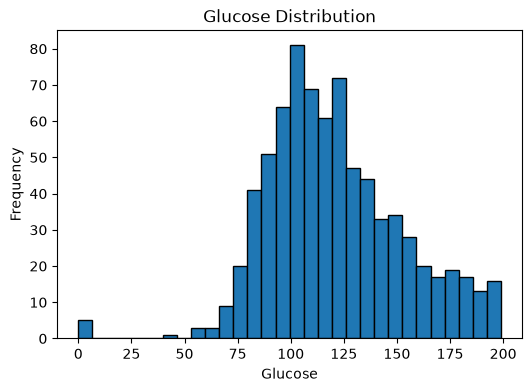

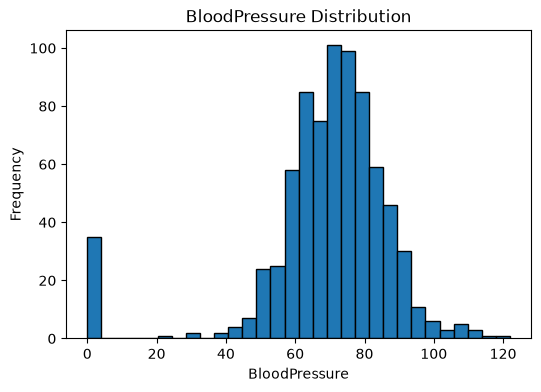

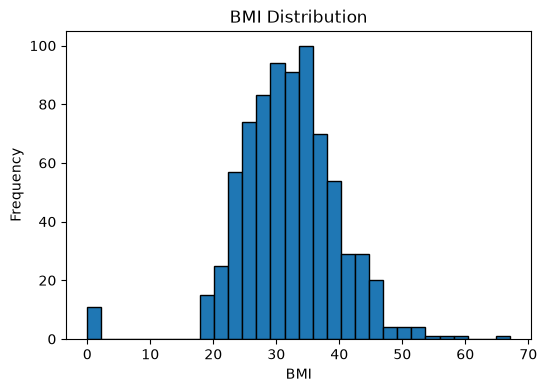

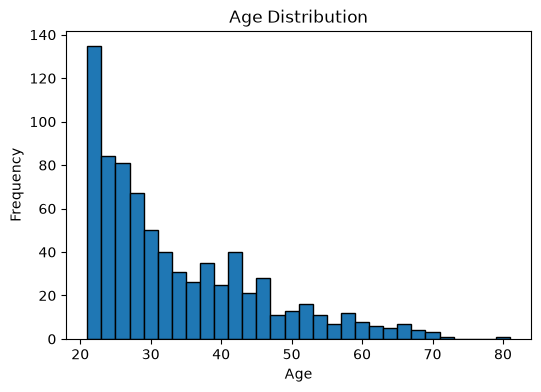

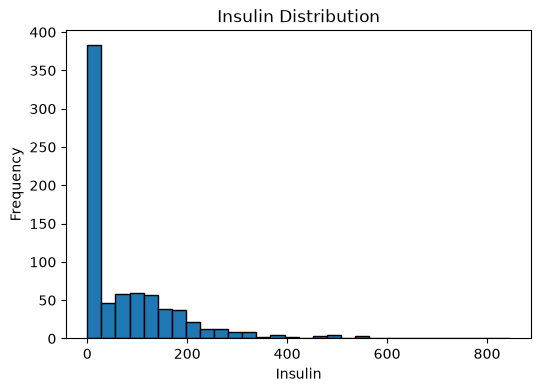

In [6]:
important_cols = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age",
    "Insulin"
]

for col in important_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

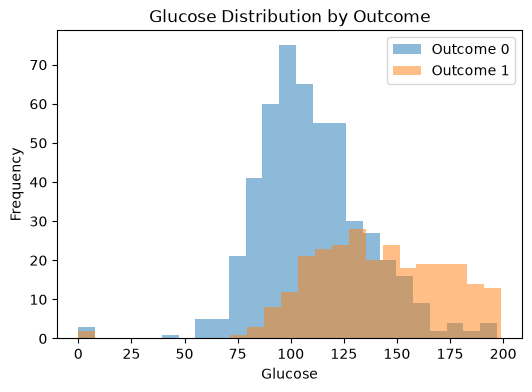

In [7]:
plt.figure(figsize=(6, 4))

plt.hist(
    df[df["Outcome"] == 0]["Glucose"],
    bins=25,
    alpha=0.5,
    label="Outcome 0"
)

plt.hist(
    df[df["Outcome"] == 1]["Glucose"],
    bins=25,
    alpha=0.5,
    label="Outcome 1"
)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Glucose Distribution by Outcome")
plt.legend()
plt.show()

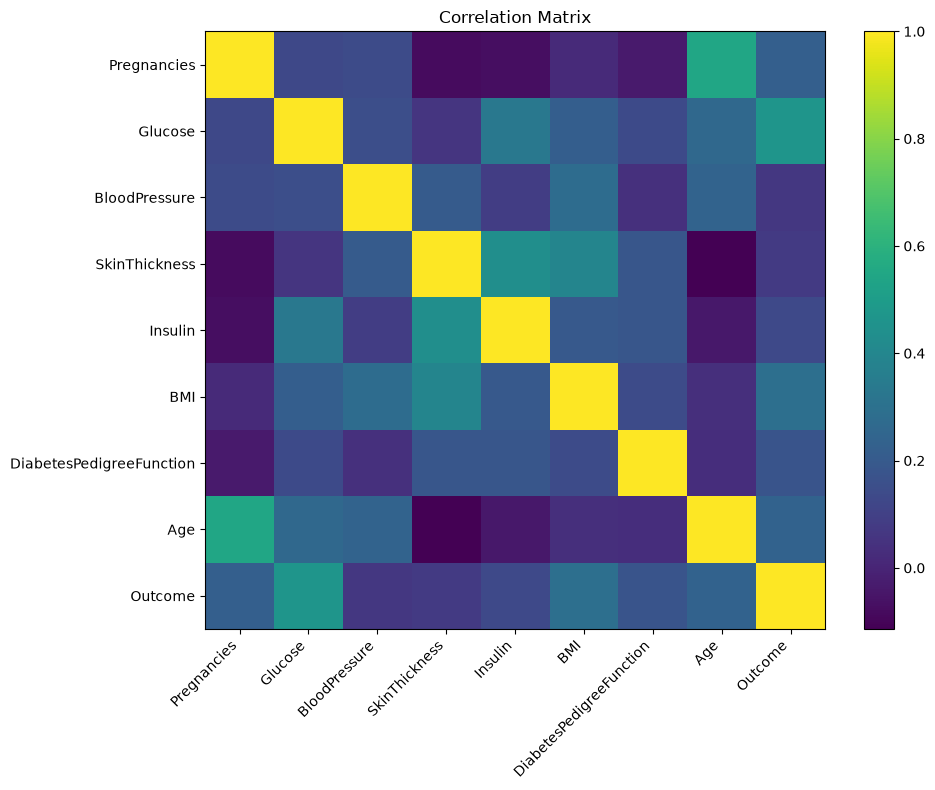

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
print(
    corr["Outcome"]
    .sort_values(ascending=False)
)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [10]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [12]:
zero_invalid_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X = X.copy()

X[zero_invalid_cols] = X[zero_invalid_cols].replace(0, np.nan)

print("[0값을 NaN으로 변환한 후 결측치 개수]")
print(X.isnull().sum())

[0값을 NaN으로 변환한 후 결측치 개수]
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [14]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

In [15]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

X_test_processed = preprocessing_pipeline.transform(X_test)

print("전처리 완료")

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

전처리 완료
X_train_processed: (614, 8)
X_test_processed: (154, 8)


In [16]:
# Train 데이터 전처리
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Test 데이터 전처리
X_test_processed = preprocessing_pipeline.transform(X_test)

print("전처리 완료")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

전처리 완료
X_train_processed: (614, 8)
X_test_processed: (154, 8)


In [17]:
print("Train 결측치:", np.isnan(X_train_processed).sum())
print("Test 결측치:", np.isnan(X_test_processed).sum())

Train 결측치: 0
Test 결측치: 0


In [18]:
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("범주형 변수:", categorical_cols)

범주형 변수: []


## 전처리 방식 선택 근거

### 1. 생리학적 오류인 0값 처리
데이터를 확인해보니 Glucose, BloodPressure, SkinThickness, Insulin, BMI 변수에 0값이 포함되어 있었음.
해당 변수들은 실제 측정값이 0이라고 보기 어렵기 때문에, 단순한 숫자 0이 아니라 결측치로 판단하여 NaN으로 변경하였음.

반면 Pregnancies는 임신 횟수가 0인 경우가 실제로 가능하기 때문에 별도의 결측치 처리를 하지 않음.

### 2. Median을 이용한 결측치 대체
변수들의 분포를 확인했을 때 일부 데이터에서 이상치와 한쪽으로 치우친 분포가 나타났음.
이런 경우 평균값을 사용하면 일부 큰 값에 영향을 받을 수 있다고 판단하여, 상대적으로 이상치의 영향을 덜 받는 중앙값(Median)으로 결측치를 대체함.

### 3. RobustScaler 적용
Insulin을 비롯한 일부 변수에서 값의 범위가 크고 이상치도 확인됨.
따라서 평균과 표준편차를 기준으로 하는 StandardScaler보다는 중앙값과 사분위 범위(IQR)를 사용하는 RobustScaler가 이번 데이터에 더 적합하다고 판단.

이를 통해 이상치의 영향을 줄이면서 변수들의 스케일 차이도 조정.

### 4. 데이터 누수 방지
Train/Test 데이터를 먼저 분리한 후,
Train 데이터에 대해서만 fit_transform()을 수행하였음.

Test 데이터에는 Train 데이터에서 학습한 전처리 기준을 이용하여
transform()만 수행함으로써 Test 데이터의 정보가 학습 과정에
미리 반영되는 Data Leakage를 방지함.

### 5. 범주형 변수 인코딩
독립변수의 데이터 타입을 확인한 결과 별도의 범주형 변수가 존재하지 않아
One-Hot Encoding은 적용하지 않음.

종속변수 Outcome 역시 이미 0과 1의 이진 값으로 표현되어 있으므로
추가적인 인코딩은 수행하지 않음.

2.머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

In [19]:
X_train_processed
X_test_processed
y_train
y_test

44     0
672    0
700    0
630    1
81     0
      ..
32     0
637    0
593    0
425    1
273    0
Name: Outcome, Length: 154, dtype: int64

① 기본 Logistic Regression 모델 학습

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 기본 모델 생성
base_model = LogisticRegression(max_iter=1000)

# 모델 학습
base_model.fit(X_train_processed, y_train)

# 예측
y_pred_base = base_model.predict(X_test_processed)

# 성능 평가
base_accuracy = accuracy_score(y_test, y_pred_base)
base_precision = precision_score(y_test, y_pred_base)
base_recall = recall_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)

print("=== 기본 모델 성능 ===")
print(f"Accuracy : {base_accuracy:.4f}")
print(f"Precision: {base_precision:.4f}")
print(f"Recall   : {base_recall:.4f}")
print(f"F1 Score : {base_f1:.4f}")

=== 기본 모델 성능 ===
Accuracy : 0.7013
Precision: 0.5870
Recall   : 0.5000
F1 Score : 0.5400


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_base)

print("=== Confusion Matrix ===")
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_base))

=== Confusion Matrix ===
[[81 19]
 [27 27]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



## 2-2. 모델 평가 및 결과 분석

이번 과제는 Outcome의 0과 1을 예측하는 이진 분류 문제이기 때문에
기본적인 분류 성능을 확인하기 위해 Accuracy를 사용하였다.

다만 당뇨병 데이터에서는 단순히 전체 정답 비율만 확인하는 것보다
실제 당뇨 환자를 얼마나 잘 찾아내는지도 중요하다고 판단하였다.
따라서 Accuracy와 함께 Precision, Recall, F1-score를 추가로 확인하였다.

특히 실제 당뇨 환자를 정상으로 예측하는 False Negative의 경우
질환을 발견하지 못하는 오류이기 때문에 Recall을 중요하게 확인하였다.

기본 Logistic Regression 모델의 Accuracy는 약 70%로 나타났다.
전체 154개의 Test 데이터 중 정상(0)은 100명, 당뇨(1)는 54명이었으며,
정상 100명 중 81명은 정상으로 정확하게 예측하였다.

반면 실제 당뇨 환자 54명 중 당뇨로 정확하게 예측한 경우는 27명이었고,
나머지 27명은 정상으로 잘못 예측하였다.
이에 따라 당뇨 클래스의 Recall은 0.50으로 나타났다.

특히 당뇨병 예측에서는 실제 환자를 정상으로 판단하는 False Negative가
중요한 오류라고 생각한다. 현재 모델은 실제 당뇨 환자의 절반 정도만
찾아내고 있기 때문에 Accuracy 70%만으로 모델의 성능이 충분하다고
판단하기는 어렵다.

이러한 오류는 정상군과 당뇨군 사이에 일부 특성이 겹쳐 있을 수 있고,
현재 데이터에 포함된 Glucose, BMI, Insulin 등의 변수만으로
당뇨 여부를 완전히 구분하기 어렵기 때문이라고 판단하였다.
또한 결측값과 이상치, 데이터에 포함되지 않은 생활습관이나 가족력 등의
요인도 예측 성능에 영향을 줄 수 있다고 생각한다.

따라서 다음 단계에서는 규제, 교차검증 및 하이퍼파라미터 튜닝을 적용하여
모델의 일반화 성능을 확인하고, 특히 당뇨 환자에 대한 Recall과
F1-score가 개선되는지도 함께 비교하고자 한다.

## 문항 2-3. 규제 + 교차검증 + 하이퍼파라미터 튜닝

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# L2 규제가 적용된 Logistic Regression
tuning_model = LogisticRegression(
    max_iter=1000
)

# 하이퍼파라미터 후보
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "max_iter": [500, 1000, 2000]
}

# 5-Fold 교차검증 + 하이퍼파라미터 튜닝
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

# 학습
grid_search.fit(X_train_processed, y_train);

In [23]:
print("최적 하이퍼파라미터:", grid_search.best_params_)
print(f"최고 교차검증 Accuracy: {grid_search.best_score_:.4f}")

최적 하이퍼파라미터: {'C': 1, 'max_iter': 500}
최고 교차검증 Accuracy: 0.6514


In [24]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_processed)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("=== 개선 모델 성능 ===")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")

=== 개선 모델 성능 ===
Accuracy : 0.7013
Precision: 0.5870
Recall   : 0.5000
F1 Score : 0.5400


In [25]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["기본 모델", "개선 모델"],
    "Accuracy": [base_accuracy, tuned_accuracy],
    "Precision": [base_precision, tuned_precision],
    "Recall": [base_recall, tuned_recall],
    "F1 Score": [base_f1, tuned_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,기본 모델,0.701299,0.586957,0.5,0.54
1,개선 모델,0.701299,0.586957,0.5,0.54


In [26]:
base_train_accuracy = base_model.score(
    X_train_processed,
    y_train
)

base_test_accuracy = base_model.score(
    X_test_processed,
    y_test
)

tuned_train_accuracy = best_model.score(
    X_train_processed,
    y_train
)

tuned_test_accuracy = best_model.score(
    X_test_processed,
    y_test
)

overfitting_comparison = pd.DataFrame({
    "Model": ["기본 모델", "개선 모델"],
    "Train Accuracy": [
        base_train_accuracy,
        tuned_train_accuracy
    ],
    "Test Accuracy": [
        base_test_accuracy,
        tuned_test_accuracy
    ]
})

overfitting_comparison

,Model,Train Accuracy,Test Accuracy
0,기본 모델,0.796417,0.701299
1,개선 모델,0.796417,0.701299


## 모델 성능 개선 및 과적합 점검

기본 모델의 과적합을 줄이고 보다 안정적인 성능을 얻기 위해
규제, 교차검증, 하이퍼파라미터 튜닝을 적용하였다.

### 1. 규제(Regularization)

Logistic Regression에 L2 규제를 적용하였다.
L2 규제는 모델의 계수가 지나치게 커지는 것을 제한하여
특정 변수에 과도하게 의존하는 것을 줄이고 과적합을 방지하는 데 목적이 있다.

규제 강도와 관련된 C값도 여러 후보를 설정하여 최적의 값을 탐색하였다.


### 2. 교차검증(Cross-Validation)

하나의 Train/Test 분할 결과에만 의존하지 않기 위해
5-Fold Cross-Validation을 적용하였다.

Train 데이터를 5개 구간으로 나누어 반복적으로 학습과 검증을 수행함으로써
모델의 일반화 성능을 보다 안정적으로 평가하고자 하였다.


### 3. 하이퍼파라미터 튜닝

GridSearchCV를 사용하여 C와 max_iter의 여러 조합을 비교하였다.
각 조합에 대해 5-Fold 교차검증을 수행한 뒤 가장 높은 검증 성능을 보인
파라미터를 최종 모델에 적용하였다.


### 4. 개선 전후 결과 분석

기본 모델과 개선 모델의 Accuracy, Precision, Recall, F1-score를 비교하였다.

개선 모델의 성능이 모든 지표에서 반드시 높아지는 것은 아니며,
각 지표의 변화를 함께 확인하여 모델의 성능을 판단하였다.

또한 Train Accuracy와 Test Accuracy의 차이를 비교하여 과적합 여부를 확인하였다.
두 성능의 차이가 크지 않다면 모델이 학습 데이터에만 과도하게 맞춰지기보다는
새로운 데이터에서도 비교적 안정적으로 작동한다고 해석할 수 있다.

3. Hugging Face 사전 학습된 모델을 활용한 뉴스 기사 분류 및 추론

In [27]:
import sys
import huggingface_hub
import transformers

from huggingface_hub import whoami

print("=== 환경 확인 ===")
print("Python:", sys.executable)
print("huggingface_hub:", huggingface_hub.__version__)
print("transformers:", transformers.__version__)

print("\n=== 로그인 확인 ===")
try:
    user = whoami()
    print("로그인 성공:", user["name"])
except Exception as e:
    print("로그인 실패:", type(e).__name__)
    print(e)

print("\n=== Gemma 접근 테스트 ===")
try:
    from huggingface_hub import hf_hub_download

    path = hf_hub_download(
        repo_id="google/gemma-3-1b-it",
        filename="config.json"
    )

    print("Gemma 접근 성공!")
    print(path)

except Exception as e:
    print("Gemma 접근 실패:", type(e).__name__)
    print(e)

c:\Users\csong\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== 환경 확인 ===
Python: c:\Users\csong\ax_study\04_MACHINE_LEARNING\.venv\Scripts\python.exe
huggingface_hub: 1.29.0
transformers: 5.16.1

=== 로그인 확인 ===
로그인 성공: whatuknow

=== Gemma 접근 테스트 ===
Gemma 접근 성공!
C:\Users\csong\.cache\huggingface\hub\models--google--gemma-3-1b-it\snapshots\dcc83ea841ab6100d6b47a070329e1ba4cf78752\config.json


c:\Users\csong\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\csong\.cache\huggingface\hub\models--google--gemma-3-1b-it. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [28]:
from transformers import pipeline

pipe = pipeline("feature-extraction", model="rkdaldus/ko-sent5-classification")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5548.80it/s]


In [29]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("rkdaldus/ko-sent5-classification")
model = AutoModel.from_pretrained("rkdaldus/ko-sent5-classification", device_map="auto")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13445.66it/s]


In [30]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_path = r"C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project"

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    local_files_only=True,
    device_map="auto",
    torch_dtype="auto"
)

print("로컬 모델 로드 완료")

Loading weights: 0it [00:00, ?it/s]
[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] GemmaForCausalLM LOAD REPORT from: C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project
Key                                                                    | Status     | 
-----------------------------------------------------------------------+------------+-
model.decoder.layers.{0, 1, 2, 3, 4, 5}.fc2.weight                     | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight        | UNEXPECTED | 
model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.q_proj.bias          | UNEXPECTED | 
model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.out_proj.bias        | UNEXPECTED | 
model.encoder.layers.{0, 1, 2, 3, 4, 5}.final_layer_norm.weight        | UNEXP

로컬 모델 로드 완료


In [31]:
few_shot_prompt = """
다음 뉴스 기사를 아래 5개 카테고리 중 하나로 분류하세요.

카테고리:
정치, 경제, 사회, 스포츠, IT

아래 예시를 참고하세요.

예시 1
뉴스: 정부가 새로운 부동산 정책을 발표하고 국회에서 관련 법안 논의가 진행되고 있다.
카테고리: 정치

예시 2
뉴스: 한국은행이 기준금리를 동결하면서 금융시장과 원화 환율의 움직임에 관심이 집중되고 있다.
카테고리: 경제

예시 3
뉴스: 프로야구 경기에서 서울 팀이 연장전 끝에 역전승을 거두었다.
카테고리: 스포츠

예시 4
뉴스: 국내 AI 기업이 새로운 생성형 인공지능 모델을 공개했다.
카테고리: IT

예시 5
뉴스: 수도권 지하철에서 발생한 사고로 출근길 시민들이 불편을 겪었다.
카테고리: 사회

이제 다음 뉴스를 분류하세요.

뉴스:
삼성전자가 차세대 인공지능 반도체 개발을 위해 연구개발 투자를 확대한다고 발표했다.

카테고리:
"""

In [32]:
messages = [
    {
        "role": "user",
        "content": few_shot_prompt
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(model.device)

print("입력 데이터 생성 완료")

입력 데이터 생성 완료


In [33]:
missing = []

for name, param in model.named_parameters():
    if param.device.type == "meta":
        missing.append(name)

print("meta 상태 weight 개수:", len(missing))
print(missing[:20])

meta 상태 weight 개수: 0
[]


In [34]:
import os

model_path = r"C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\gemma-3-1b-it"

print("폴더 존재:", os.path.exists(model_path))

if os.path.exists(model_path):
    for file in os.listdir(model_path):
        print(file)

폴더 존재: False


In [35]:
import os

base_path = r"C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if (
            "gemma" in root.lower()
            or file.endswith(".safetensors")
            or file == "config.json"
            or file == "tokenizer.json"
            or file == "tokenizer_config.json"
        ):
            print(os.path.join(root, file))

C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\config.json
C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\model-00002-of-00002.safetensors
C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\model.safetensors
C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\tokenizer.json
C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project\tokenizer_config.json


In [36]:
import os

model_path = r"C:\Users\csong\ax_study\04_MACHINE_LEARNING\Second_project"

for file in os.listdir(model_path):
    if file.endswith(".safetensors") or file.endswith(".json"):
        full_path = os.path.join(model_path, file)
        size_mb = os.path.getsize(full_path) / (1024 ** 2)
        print(f"{file:45} {size_mb:,.2f} MB")

config.json                                   0.00 MB
generation_config.json                        0.00 MB
model-00002-of-00002.safetensors              64.01 MB
model.safetensors                             472.63 MB
model.safetensors.index.json                  0.01 MB
special_tokens_map.json                       0.00 MB
tokenizer.json                                16.71 MB
tokenizer_config (1).json                     0.03 MB
tokenizer_config.json                         0.03 MB


In [37]:
import os

files = os.listdir(model_path)

print("1번 shard 존재:",
      "model-00001-of-00002.safetensors" in files)

print("2번 shard 존재:",
      "model-00002-of-00002.safetensors" in files)

print("index 존재:",
      "model.safetensors.index.json" in files)

print("단일 model 존재:",
      "model.safetensors" in files)

1번 shard 존재: False
2번 shard 존재: True
index 존재: True
단일 model 존재: True


In [ ]:
from transformers import pipeline
import torch

# Gemma 인스트럭션 모델 식별자 설정
gemma_identifier = "google/gemma-2b-it"

# 텍스트 생성 파이프라인 구축 (bfloat16 연산 및 자원 자동 배치 적용)
gemma_generator = pipeline(
    "text-generation",
    model=gemma_identifier,
    dtype=torch.bfloat16,
    device_map="auto" # accelerate를 통해 OS별 하드웨어(CUDA/MPS) 최적 자동 할당
)

# 대화형 프롬프트 구조 정의
user_dialogue = [
    {"role": "user", "content": """
당신은 뉴스 분류 전문가입니다.
아래 뉴스 기사를 정치, 경제, 사회, 스포츠, IT 중 하나로 분류하세요.
답변은 반드시 카테고리 이름 하나만 출력하세요.

[예시 1]
뉴스 기사: 국회에서 새로운 선거법 개정안을 논의했습니다.
분류: 정치

[예시 2]
뉴스 기사: 한국은행이 기준금리를 동결했습니다.
분류: 경제

[예시 3]
뉴스 기사: 수도권 집중호우로 일부 도로가 통제되었습니다.
분류: 사회

[예시 4]
뉴스 기사: 프로야구 경기에서 홈팀이 역전승을 거두었습니다.
분류: 스포츠

[예시 5]
뉴스 기사: 국내 기업이 새로운 생성형 AI 서비스를 공개했습니다.
분류: IT

[분류할 뉴스]
뉴스 기사: 삼성전자가 차세대 AI 반도체 개발을 위해 연구개발 투자를 확대한다고 발표했습니다.

분류:
"""}
]

# 답변 생성
generation_outputs = gemma_generator(user_dialogue, max_new_tokens=150)

# 최종 답변 추출 및 출력
ai_reply = generation_outputs[0]["generated_text"][-1]["content"]
print("--- Gemma 답변 ---")
print(f"Gemma의 답변:\n{ai_reply}")

c:\Users\csong\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
generation_outputs = gemma_generator(
    user_dialogue,
    max_new_tokens=20,
    do_sample=False
)

ai_reply = generation_outputs[0]["generated_text"][-1]["content"]

print("=== Gemma 뉴스 분류 결과 ===")
print(ai_reply)

### 문항 3-2. Few-shot 기반 뉴스 기사 분류

정치, 경제, 사회, 스포츠, IT의 뉴스 기사와 정답 카테고리를
Few-shot 예시로 프롬프트에 입력함.

별도의 모델 파인튜닝 없이 사전 학습된 Gemma 모델이
프롬프트에 제공된 예시를 문맥으로 참고하여 새로운 뉴스 기사의
카테고리를 추론하도록 구성함.

In [ ]:
output_a = gemma_generator(
    user_dialogue,
    max_new_tokens=20,
    do_sample=False
)

result_a = output_a[0]["generated_text"][-1]["content"].strip()

print("실험 A 결과:", result_a)

In [ ]:
output_b = gemma_generator(
    user_dialogue,
    max_new_tokens=20,
    do_sample=True,
    temperature=0.3,
    top_p=0.8,
    top_k=20
)

result_b = output_b[0]["generated_text"][-1]["content"].strip()

print("실험 B 결과:", result_b)

In [ ]:
output_c = gemma_generator(
    user_dialogue,
    max_new_tokens=20,
    do_sample=True,
    temperature=1.0,
    top_p=0.95,
    top_k=50
)

result_c = output_c[0]["generated_text"][-1]["content"].strip()

print("실험 C 결과:", result_c)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "실험": ["A", "B", "C"],
    "do_sample": [False, True, True],
    "temperature": ["미사용", 0.3, 1.0],
    "top_p": ["미사용", 0.8, 0.95],
    "top_k": ["미사용", 20, 50],
    "분류 결과": [result_a, result_b, result_c]
})

comparison

### Generation 하이퍼파라미터 변경 결과 분석

동일한 Few-shot 프롬프트를 사용하고 temperature, top_p, top_k 값을
변경하여 뉴스 분류 결과를 비교하였다.

실험 결과 세 조건에서 동일한 카테고리가 출력되어 이번 뉴스 기사에서는
Generation 하이퍼파라미터 변화에도 분류 결과가 비교적 일관되게 나타났다.

특히 do_sample=False 조건에서는 가장 확률이 높은 토큰을 중심으로
결과를 생성하기 때문에 분류와 같이 정해진 답을 요구하는 작업에서
상대적으로 안정적인 결과를 얻을 수 있었다.

반면 temperature와 top_p, top_k 값을 높여 샘플링 범위를 넓히면
생성 결과의 다양성이 증가할 수 있으므로, 창의적인 텍스트 생성에는
유용하지만 뉴스 카테고리 분류에서는 답변의 일관성이 낮아질 가능성이 있다.